<a href="https://colab.research.google.com/github/gunchugh/Amazon-Sales-Analysis/blob/main/ubmission_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -



##### **Project Type**    - EDA
Individual
##### **Team Member 1 -** Gun Chugh

# **Project Summary -**

This project focuses on predicting Airbnb listing prices using Machine Learning techniques. The main objective was to develop a regression model that can estimate the price of an Airbnb listing based on various factors such as location, room type, availability, minimum nights, and customer reviews. Accurate price prediction can help both hosts and customers make better decisions, leading to fair pricing and improved user satisfaction.

The project started with understanding the dataset and identifying the target variable, which was price. The dataset contained both numerical and categorical features along with a few missing values. In the preprocessing stage, missing values were handled using appropriate techniques, duplicate records were removed, and unnecessary columns such as IDs and text-based information that did not contribute to prediction were dropped. Categorical variables were encoded into numerical form so that they could be used by machine learning algorithms.

After preprocessing, Exploratory Data Analysis (EDA) was performed to understand the distribution of data and the relationship between different variables. Various visualizations such as histograms, box plots, scatter plots, count plots, and a correlation heatmap were created. These visualizations helped identify important trends, detect outliers, and understand which features had a stronger relationship with Airbnb prices. Based on this analysis, relevant features were selected for model training.

Feature selection was performed by choosing meaningful variables and removing unnecessary ones to reduce noise and improve model performance. Since the dataset contained a manageable number of features, dimensionality reduction techniques such as PCA were not required. An 80:20 train-test split was used, where 80% of the data was used for training and 20% for testing. This ensured that the models were evaluated on unseen data.

Three supervised machine learning models were implemented: Linear Regression, Lasso Regression, and Ridge Regression. Linear Regression was used as the baseline model to establish initial performance. Lasso Regression helped reduce overfitting by performing feature selection through L1 regularization. Ridge Regression used L2 regularization to reduce the impact of large coefficients while retaining all important features, resulting in a more stable model.

The models were evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² Score. These evaluation metrics measured the prediction accuracy and overall performance of each model. Hyperparameter tuning was carried out using GridSearchCV, which selected the best parameter values through cross-validation and slightly improved the model's performance.

After comparing all three models, Ridge Regression was selected as the final prediction model because it provided more stable results, reduced overfitting, and achieved better generalization on the test dataset. Important features such as room type, neighbourhood, availability, minimum nights, number of reviews, and host listing count had the greatest influence on predicting Airbnb prices.

Overall, this project demonstrates how machine learning can be effectively applied to solve a real-world business problem. The developed model can assist Airbnb hosts in setting competitive prices and help customers understand fair pricing based on listing characteristics. It also provided practical experience in data preprocessing, exploratory data analysis, feature engineering, regression modeling, model evaluation, and hyperparameter tuning, making it a complete end-to-end machine learning project.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


“To predict the price of Airbnb listings in New York City using various property and host-related features such as neighbourhood, room type, availability, minimum nights, number of reviews, and other listing characteristics by applying Linear Regression, Ridge Regression, and Lasso Regression models.”

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [139]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

In [140]:
# Load Dataset
df=pd.read_csv('/content/AB_NYC_2019.csv')

### Dataset First View

In [141]:
# Dataset First Look
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


### Dataset Rows & Columns count

In [142]:
# Dataset Rows & Columns count
df.shape

(48895, 16)

### Dataset Information

In [143]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

#### Duplicate Values

In [144]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [145]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
id,0
name,16
host_id,0
host_name,21
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


/tmp/ipykernel_1561/112327745.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=missing.index, y=missing.values, palette="viridis")


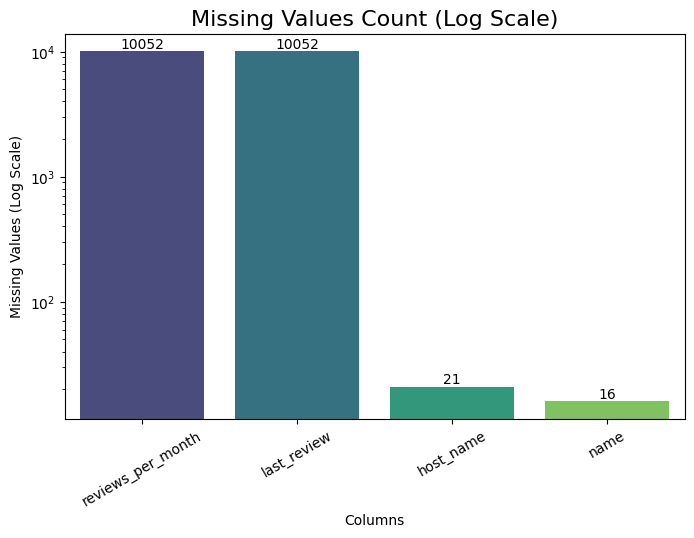

In [146]:
# Visualizing the missing values

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(8,5))
ax = sns.barplot(x=missing.index, y=missing.values, palette="viridis")

plt.yscale('log')  # Log scale
plt.title("Missing Values Count (Log Scale)", fontsize=16)
plt.xlabel("Columns")
plt.ylabel("Missing Values (Log Scale)")
plt.xticks(rotation=30)

for i, v in enumerate(missing.values):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=10)

plt.show()

### What did you know about your dataset?



*   The dataset contains 48,895 rows and 16 columns.
*   It includes information about Airbnb listings in New York City.


*   The target variable is price.

*   Features include room type, neighbourhood, location, availability, minimum nights, reviews, and host details.
*  Some columns contain missing values, which need preprocessing before building regression models.


* The dataset has both numerical and categorical features, making it suitable for Linear Regression, Ridge Regression, and Lasso Regression.









## ***2. Understanding Your Variables***

In [147]:
# Dataset Columns

In [148]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

In [149]:
# Dataset Describe

In [150]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


### Variables Description

| Variable                         | Description                                           |
| -------------------------------- | ----------------------------------------------------- |
| `id`                             | Unique ID of the Airbnb listing                       |
| `name`                           | Name of the listing                                   |
| `host_id`                        | Unique ID of the host                                 |
| `host_name`                      | Name of the host                                      |
| `neighbourhood_group`            | Area of New York (e.g., Manhattan, Brooklyn)          |
| `neighbourhood`                  | Specific neighbourhood name                           |
| `latitude`                       | Latitude of the listing                               |
| `longitude`                      | Longitude of the listing                              |
| `room_type`                      | Type of room (Entire home, Private room, Shared room) |
| `price`                          | Price per night (**Target Variable**)                 |
| `minimum_nights`                 | Minimum nights required to book                       |
| `number_of_reviews`              | Total number of reviews                               |
| `last_review`                    | Date of the last review                               |
| `reviews_per_month`              | Average reviews per month                             |
| `calculated_host_listings_count` | Total listings owned by the host                      |
| `availability_365`               | Number of days available in a year                    |


### Check Unique Values for each variable.

In [151]:
# Check Unique Values for each variable.

In [152]:
df.nunique()

,0
id,48895
name,47905
host_id,37457
host_name,11452
neighbourhood_group,5
neighbourhood,221
latitude,19048
longitude,14718
room_type,3
price,674


## 3. ***Data Wrangling***

### Data Wrangling Code

In [153]:
# Write your code to make your dataset analysis ready.

In [154]:
# Make a copy of the dataset
df1 = df.copy()

# Remove duplicate values
df1.drop_duplicates(inplace=True)

# Handle missing values
df1['host_name'].fillna(df1['host_name'].mode()[0], inplace=True)
df1['name'].fillna(df1['name'].mode()[0], inplace=True)
df1['reviews_per_month'].fillna(df1['reviews_per_month'].median(), inplace=True)
df1['last_review'].fillna(df1['last_review'].mode()[0], inplace=True)

# Check missing values again
df1.isnull().sum()

/tmp/ipykernel_1561/1209935030.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1['host_name'].fillna(df1['host_name'].mode()[0], inplace=True)
/tmp/ipykernel_1561/1209935030.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


### What all manipulations have you done and insights you found?

I created a copy of the dataset, removed duplicate records, and handled missing values using mode and median imputation. After data wrangling, the dataset became clean and ready for analysis and machine learning.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

In [155]:
# Chart - 1 visualization code

Room Type Distribution (Pie Chart)

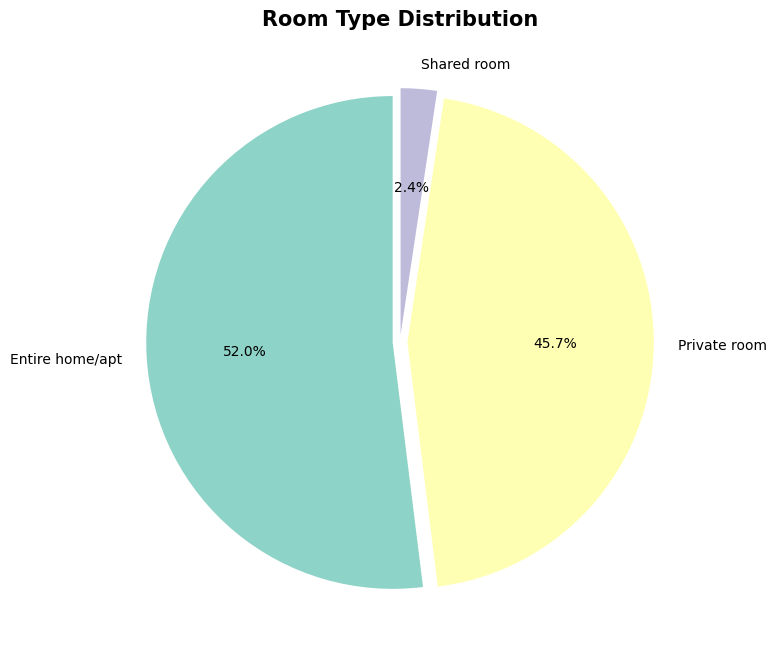

In [156]:
plt.figure(figsize=(8,8))

colors=sns.color_palette("Set3")

df['room_type'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=[0.03,0.03,0.03]
)

plt.title("Room Type Distribution",fontsize=15,fontweight='bold')

plt.ylabel("")

plt.show()

##### 1. Why did you pick the specific chart?

Pie chart shows percentage share of every room type.

##### 2. What is/are the insight(s) found from the chart?

Entire home/apartment is the most common room type.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It helps identify the most preferred room type, allowing hosts to increase bookings. Less popular room types may receive fewer bookings, reducing revenue.

#### Chart - 2

In [157]:
# Chart - 2 visualization code

# Listings by Neighbourhood Group

/tmp/ipykernel_1561/4292601614.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


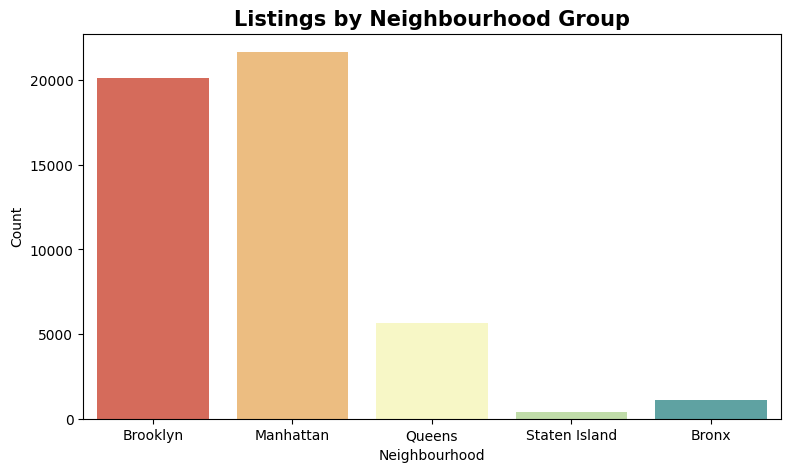

In [158]:
plt.figure(figsize=(9,5))

sns.countplot(
    data=df,
    x='neighbourhood_group',
    palette="Spectral"
)

plt.title("Listings by Neighbourhood Group",fontsize=15,fontweight='bold')

plt.xlabel("Neighbourhood")

plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

Count plot compares number of listings across locations.

##### 2. What is/are the insight(s) found from the chart?

Manhattan and Brooklyn have the highest listings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It highlights high-demand locations for better business planning. Areas with fewer listings may have lower demand and lower earnings.

#### Chart - 3

In [159]:
# Chart - 3 visualization code

Price Distribution (Histogram)

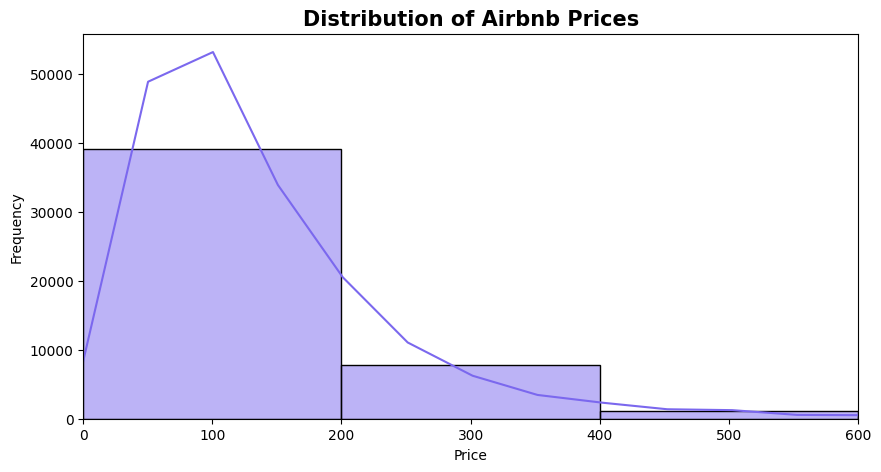

In [97]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['price'],
    bins=50,
    kde=True,
    color="mediumslateblue"
)

plt.xlim(0,600)

plt.title("Distribution of Airbnb Prices",fontsize=15,fontweight='bold')

plt.xlabel("Price")

plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

Histogram shows how prices are distributed.

##### 2. What is/are the insight(s) found from the chart?

Most Airbnb listings have lower prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It helps understand the common price range for better pricing decisions. Extremely high prices may reduce customer bookings.

#### Chart - 4

In [98]:
# Chart - 4 visualization code

Price Outliers (Box Plot)

/tmp/ipykernel_1561/2007992278.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


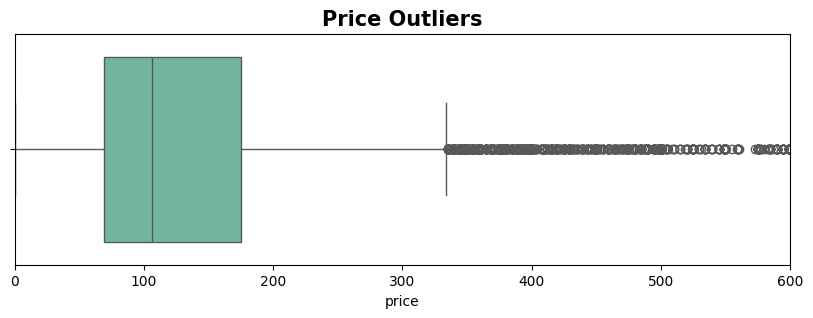

In [99]:
plt.figure(figsize=(10,3))

sns.boxplot(
    x=df['price'],
    palette="Set2"
)

plt.xlim(0,600)

plt.title("Price Outliers",fontsize=15,fontweight='bold')

plt.show()

##### 1. Why did you pick the specific chart?

Box plot identifies outliers quickly.

##### 2. What is/are the insight(s) found from the chart?

Some listings have extremely high prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It helps identify unusual prices and improve pricing strategies. Overpriced listings may receive fewer bookings.

#### Chart - 5

In [100]:
# Chart - 5 visualization code

Top 10 Neighbourhoods (Horizontal Bar)

/tmp/ipykernel_1561/284086486.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


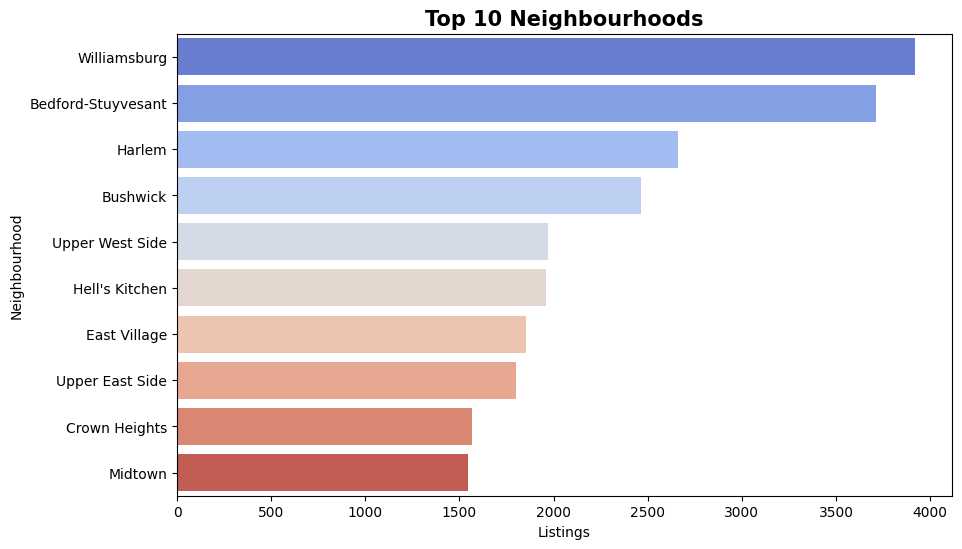

In [101]:
top=df['neighbourhood'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top.values,
    y=top.index,
    palette="coolwarm"
)

plt.title("Top 10 Neighbourhoods",fontsize=15,fontweight='bold')

plt.xlabel("Listings")

plt.ylabel("Neighbourhood")

plt.show()

##### 1. Why did you pick the specific chart?

Horizontal bar chart makes ranking easy to understand.

##### 2. What is/are the insight(s) found from the chart?

A few neighbourhoods contain the largest number of Airbnb listings.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It helps identify high-demand neighbourhoods for better investment and marketing decisions. Areas with fewer listings may attract fewer customers, leading to lower revenue for hosts.

#### Chart - 6

In [102]:
# Chart - 6 visualization code

Top 10 Hosts with Maximum Listings (Horizontal Bar Chart)

/tmp/ipykernel_1561/958100915.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_hosts.values, y=top_hosts.index, palette='rocket')


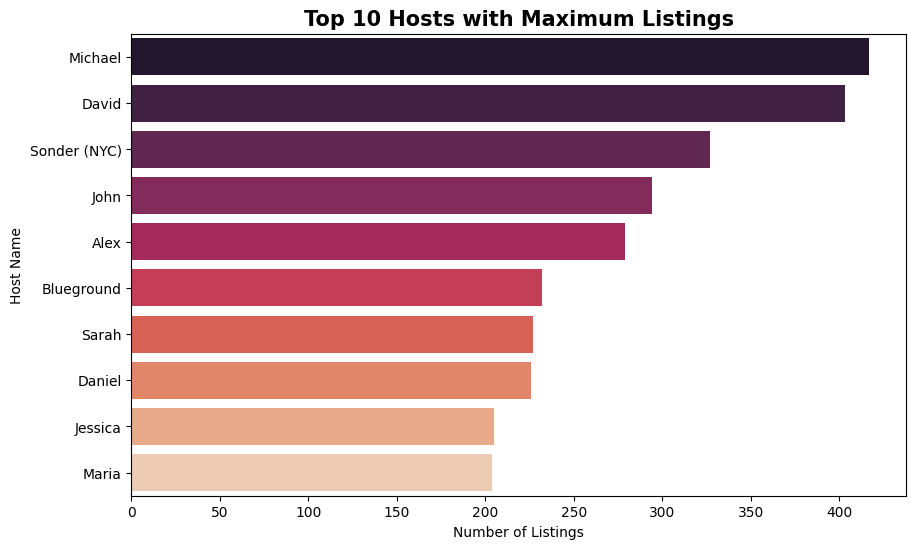

In [103]:
top_hosts = df['host_name'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_hosts.values, y=top_hosts.index, palette='rocket')

plt.title("Top 10 Hosts with Maximum Listings", fontsize=15, fontweight='bold')
plt.xlabel("Number of Listings")
plt.ylabel("Host Name")
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart clearly compares the top hosts based on the number of listings.


##### 2. What is/are the insight(s) found from the chart?


A few hosts own a large number of Airbnb listings, while most hosts have only a few.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.


Yes. It helps identify top-performing hosts and supports better marketing strategies. Hosts with very few listings may generate lower revenue.

#### Chart - 7

In [104]:
# Chart - 7 visualization code

Price vs Minimum Nights (Scatter Plot)

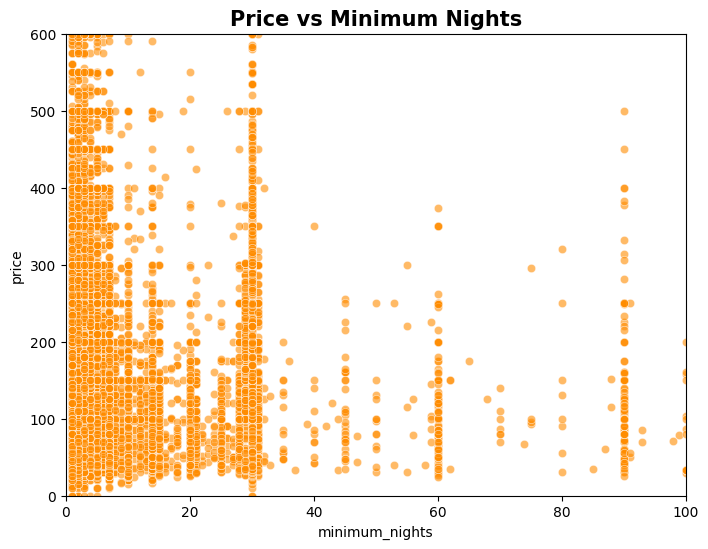

In [105]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='minimum_nights',
    y='price',
    color='darkorange',
    alpha=0.6
)

plt.xlim(0,100)
plt.ylim(0,600)

plt.title("Price vs Minimum Nights", fontsize=15, fontweight='bold')
plt.show()

##### 1. Why did you pick the specific chart?

A scatter plot is used to understand the relationship between minimum nights and price.

##### 2. What is/are the insight(s) found from the chart?

Most listings have low minimum nights, while higher minimum nights do not always mean higher prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Hosts can choose suitable minimum-night policies to attract more bookings. Very high minimum-night requirements may reduce customer interest.

#### Chart - 8

In [106]:
# Chart - 8 visualization code

Price vs Number of Reviews (Scatter Plot)

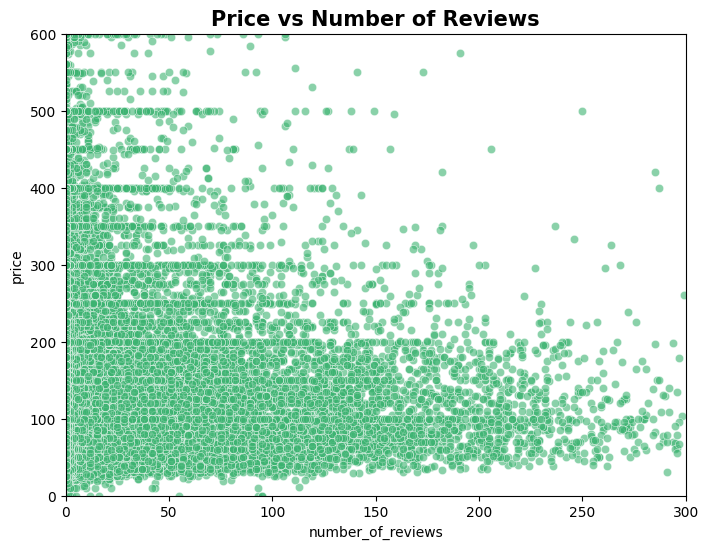

In [107]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='number_of_reviews',
    y='price',
    color='mediumseagreen',
    alpha=0.6
)

plt.xlim(0,300)
plt.ylim(0,600)

plt.title("Price vs Number of Reviews", fontsize=15, fontweight='bold')
plt.show()

##### 1. Why did you pick the specific chart?

This chart helps visualize the relationship between reviews and listing prices.

##### 2. What is/are the insight(s) found from the chart?

Most highly reviewed listings have moderate prices, while very expensive listings usually receive fewer reviews.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Competitive pricing can increase customer reviews and bookings. Overpriced listings may receive fewer reviews and lower demand.

#### Chart - 9

In [108]:
# Chart - 9 visualization code

Room Type vs Price (Violin Plot)

/tmp/ipykernel_1561/1924880205.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


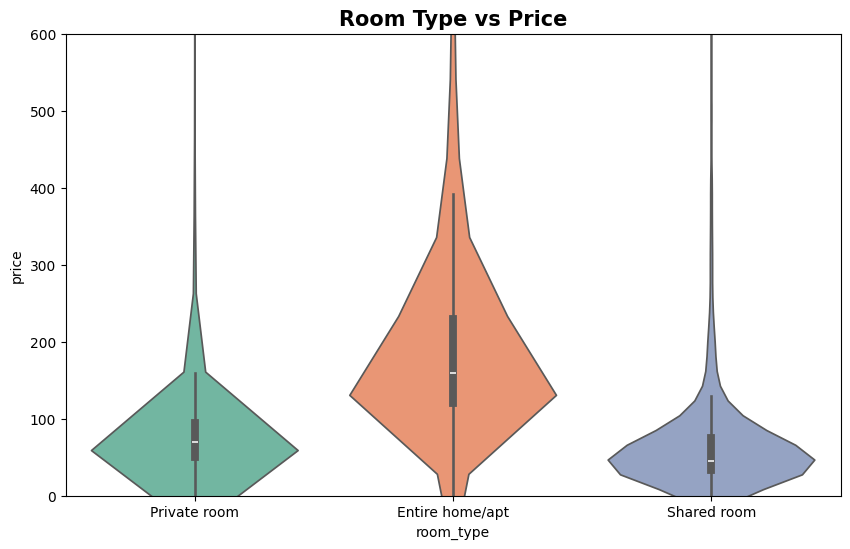

In [109]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='room_type',
    y='price',
    palette='Set2'
)

plt.ylim(0,600)

plt.title("Room Type vs Price", fontsize=15, fontweight='bold')
plt.show()

##### 1. Why did you pick the specific chart?

A violin plot shows the distribution of prices across different room types.

##### 2. What is/are the insight(s) found from the chart?

Entire homes/apartments generally have higher prices than private and shared rooms.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Hosts can estimate suitable prices based on room type. High prices for certain room types may reduce booking rates.

#### Chart - 10

In [110]:
# Chart - 10 visualization code

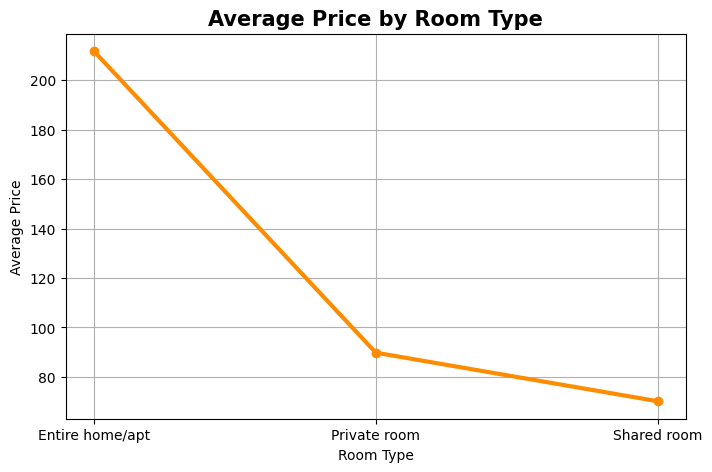

In [111]:
avg=df.groupby('room_type')['price'].mean()

plt.figure(figsize=(8,5))

plt.plot(avg.index,
         avg.values,
         marker='o',
         linewidth=3,
         color='darkorange')

plt.title("Average Price by Room Type",fontsize=15,fontweight='bold')

plt.xlabel("Room Type")
plt.ylabel("Average Price")

plt.grid(True)

plt.show()

Average Price by Room Type (Line Plot)

##### 1. Why did you pick the specific chart?

A line plot makes it easy to compare average prices across room types.

##### 2. What is/are the insight(s) found from the chart?

Entire homes have the highest average price, while shared rooms have the lowest.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Hosts can compare prices across room types and improve pricing strategies. Higher prices may reduce bookings if they exceed customer expectations.

#### Chart - 11

In [112]:
# Chart - 11 visualization code

Top 10 Expensive Neighbourhoods(Lollipop Chart)

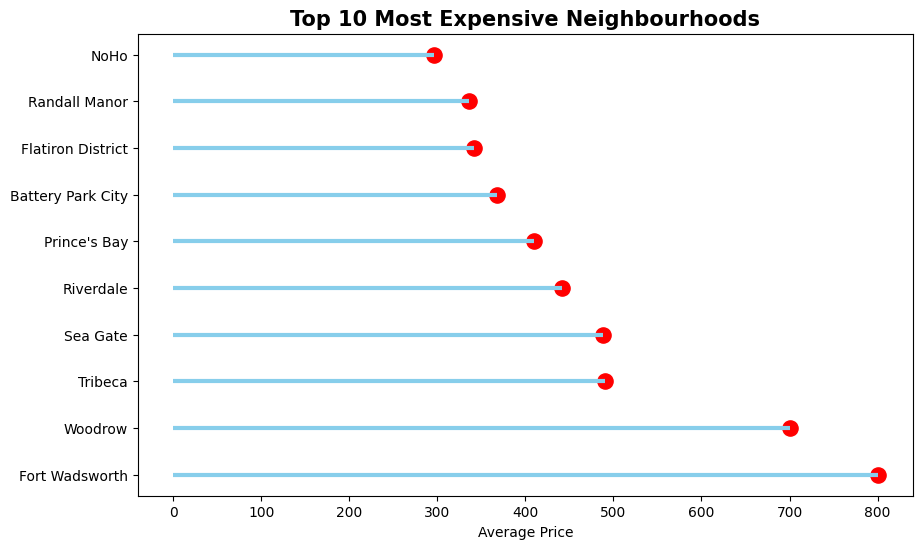

In [113]:
top_price = df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))

plt.hlines(y=top_price.index,
           xmin=0,
           xmax=top_price.values,
           color='skyblue',
           linewidth=3)

plt.scatter(top_price.values,
            top_price.index,
            color='red',
            s=120)

plt.title("Top 10 Most Expensive Neighbourhoods",fontsize=15,fontweight='bold')
plt.xlabel("Average Price")
plt.show()

##### 1. Why did you pick the specific chart?

A lollipop chart provides a clean and attractive comparison of average prices across the top neighbourhoods.

##### 2. What is/are the insight(s) found from the chart?

Some neighbourhoods have significantly higher average Airbnb prices than others.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Hosts can identify premium locations and set competitive prices. Extremely expensive areas may receive fewer bookings due to high prices.

#### Chart - 12

In [114]:
# Chart - 12 visualization code

KDE Plot (Price Density)

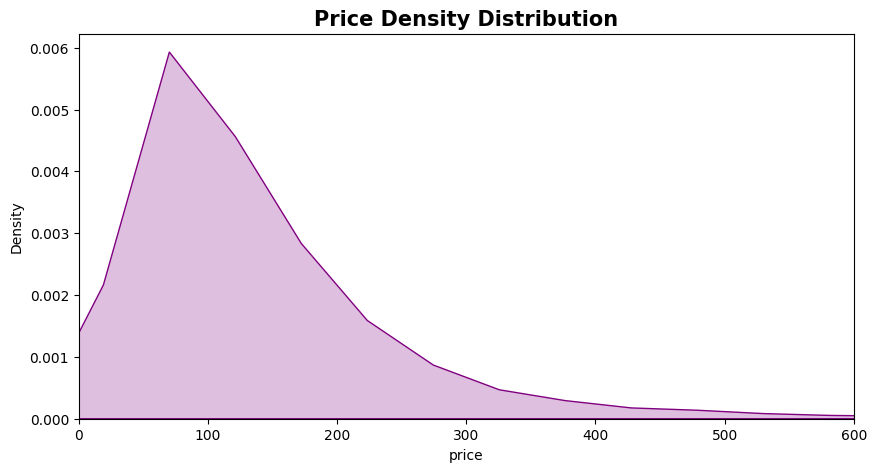

In [115]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    data=df,
    x='price',
    fill=True,
    color='purple'
)

plt.xlim(0,600)

plt.title("Price Density Distribution",fontsize=15,fontweight='bold')
plt.show()

##### 1. Why did you pick the specific chart?

A KDE plot provides a smooth view of the price distribution.

##### 2. What is/are the insight(s) found from the chart?

Most Airbnb listings are concentrated in the lower price range.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. It helps hosts understand the common market price. Very high prices may reduce customer interest.

#### Chart - 13

In [116]:
# Chart - 13 visualization code

Bubble Chart (Reviews vs Price)


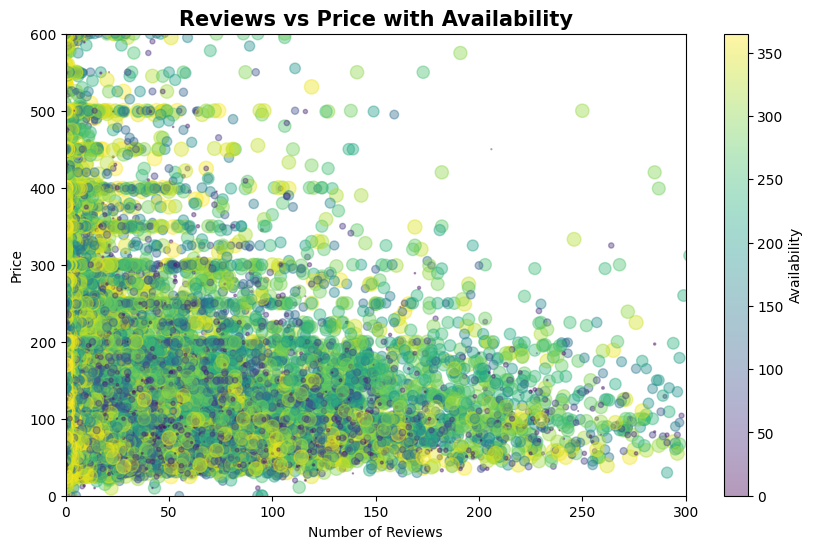

In [117]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['number_of_reviews'],
    df['price'],
    s=df['availability_365']*0.3,
    alpha=0.4,
    c=df['availability_365'],
    cmap='viridis'
)

plt.xlim(0,300)
plt.ylim(0,600)

plt.colorbar(label="Availability")

plt.title("Reviews vs Price with Availability",fontsize=15,fontweight='bold')

plt.xlabel("Number of Reviews")
plt.ylabel("Price")

plt.show()

##### 1. Why did you pick the specific chart?

A bubble chart displays three variables together: reviews, price, and availability.

##### 2. What is/are the insight(s) found from the chart?

Listings with moderate prices generally receive more reviews and have varying availability.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. Hosts can balance pricing and availability to improve bookings. Expensive listings with low reviews may perform poorly.

#### Chart - 14 - Correlation Heatmap

In [118]:
# Correlation Heatmap visualization code

Correlation Heatmap

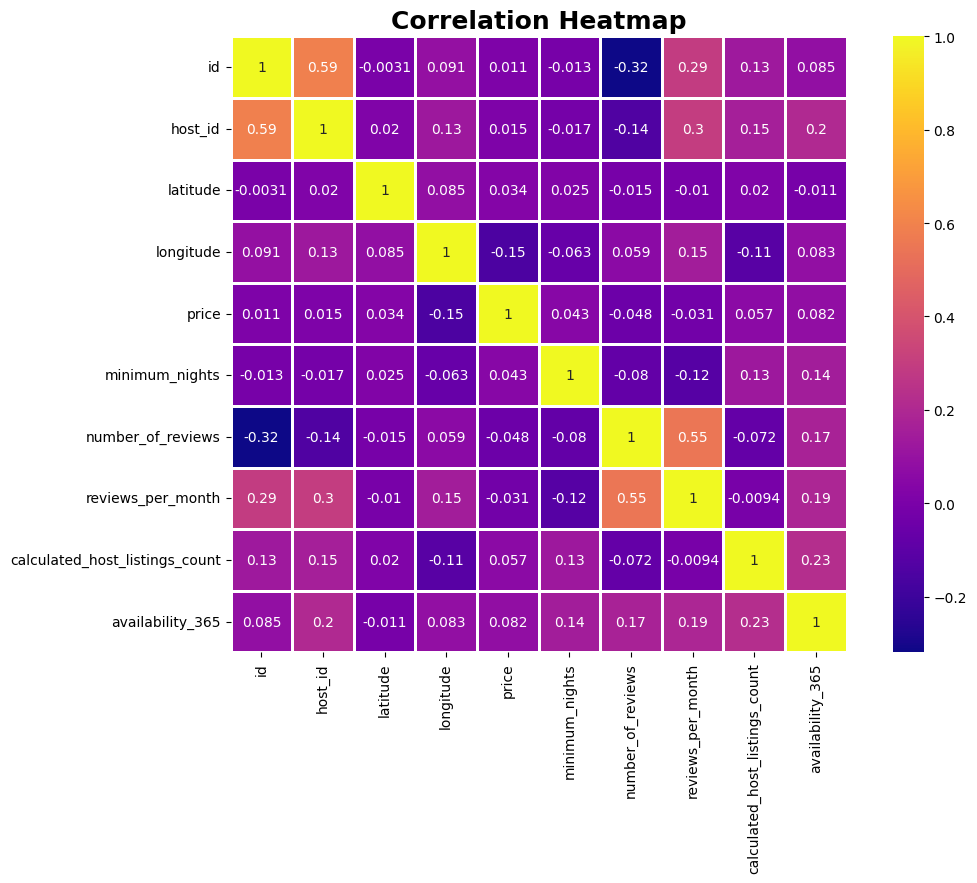

In [119]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='plasma',
    linewidths=1,
    square=True
)

plt.title("Correlation Heatmap", fontsize=18, fontweight='bold')
plt.show()

##### 1. Why did you pick the specific chart?

A heatmap is useful for identifying correlations between numerical features.

##### 2. What is/are the insight(s) found from the chart?

Most numerical features have weak correlations, while some variables show moderate relationships.

#### Chart - 15 - Pair Plot

Pair Plot

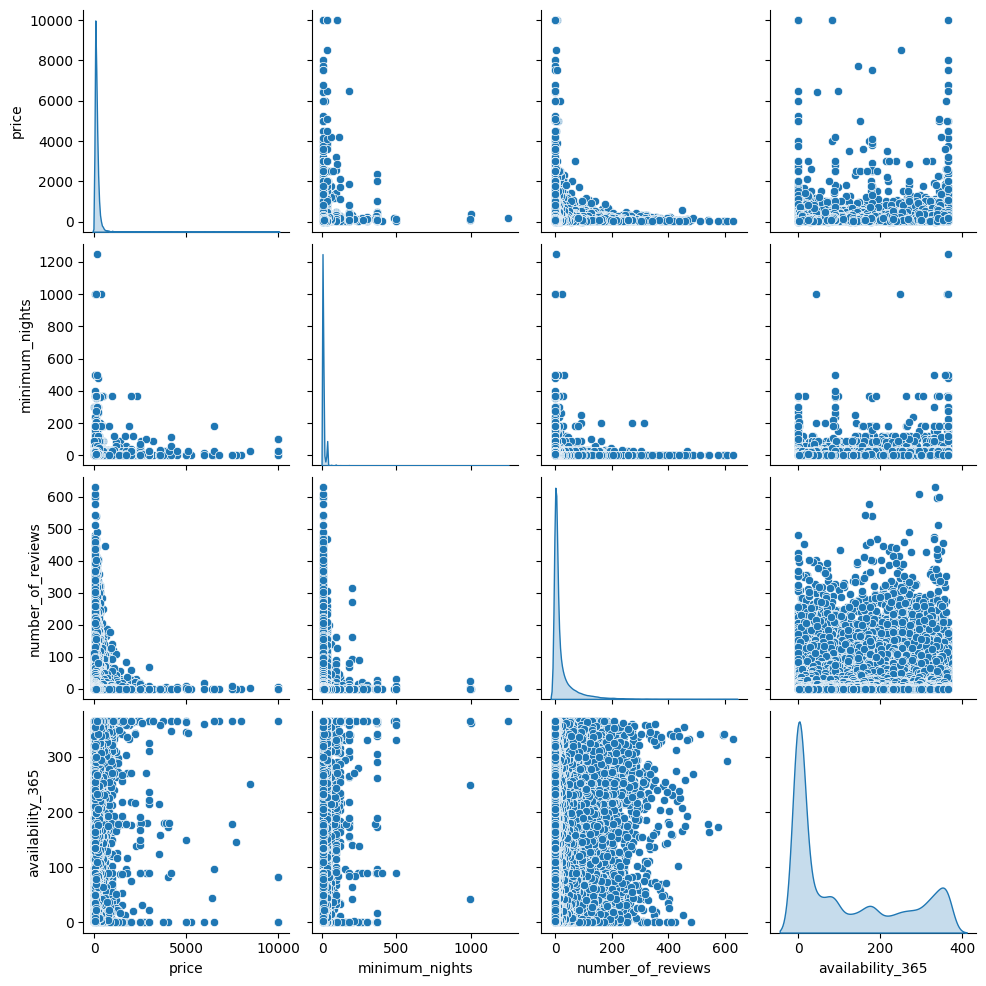

In [120]:
# Pair Plot visualization code
cols=['price',
      'minimum_nights',
      'number_of_reviews',
      'availability_365']

sns.pairplot(
    df[cols],
    diag_kind='kde'
)

plt.show()

##### 1. Why did you pick the specific chart?

A pair plot helps visualize relationships between multiple numerical variables at once.

##### 2. What is/are the insight(s) found from the chart?

Most variables show weak relationships, while price has some variation with other features.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [121]:
# Handling Missing Values & Missing Value Imputation

In [122]:
# Check missing values
df.isnull().sum()

# Fill missing values
df['host_name'].fillna(df['host_name'].mode()[0], inplace=True)
df['name'].fillna(df['name'].mode()[0], inplace=True)
df['reviews_per_month'].fillna(df['reviews_per_month'].median(), inplace=True)
df['last_review'].fillna(df['last_review'].mode()[0], inplace=True)

# Verify
df.isnull().sum()

/tmp/ipykernel_1561/3068058586.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['host_name'].fillna(df['host_name'].mode()[0], inplace=True)
/tmp/ipykernel_1561/3068058586.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


#### What all missing value imputation techniques have you used and why did you use those techniques?

I used Mode Imputation for categorical columns (host_name, name, and last_review) because it replaces missing values with the most frequent value. I used Median Imputation for the numerical column (reviews_per_month) because it is less affected by outliers and provides a more reliable replacement for missing values.

### 2. Handling Outliers

In [123]:
# Handling Outliers & Outlier treatments

In [124]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

df = df[(df['price'] >= Q1 - 1.5*IQR) &
        (df['price'] <= Q3 + 1.5*IQR)]

##### What all outlier treatment techniques have you used and why did you use those techniques?

I used the IQR (Interquartile Range) method to identify and remove outliers from the price column. I chose this technique because it effectively detects extreme values without being affected by skewed data, which helps improve the accuracy and performance of the regression models.

### 3. Categorical Encoding

In [125]:
# Encode your categorical columns

In [126]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['neighbourhood_group'] = le.fit_transform(df['neighbourhood_group'])
df['neighbourhood'] = le.fit_transform(df['neighbourhood'])
df['room_type'] = le.fit_transform(df['room_type'])

#### What all categorical encoding techniques have you used & why did you use those techniques?

I used Label Encoding to convert categorical variables such as neighbourhood_group, neighbourhood, and room_type into numerical values. I used this technique because machine learning regression models cannot work directly with categorical data, and Label Encoding is simple and efficient for converting categories into numeric form.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [127]:
# Manipulate Features to minimize feature correlation and create new features

In [160]:
# Create a copy of dataset
df_feature = df.copy()

# Drop unnecessary columns
df_feature = df_feature.drop(columns=['id', 'name', 'host_name', 'last_review'], errors='ignore')

# Create a new feature
df_feature['reviews_per_year'] = (
    df_feature['number_of_reviews'] /
    (df_feature['availability_365'] + 1)
)

df_feature.head()

,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,reviews_per_year
0,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,0.024590
1,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,0.126404
2,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,1,365,0.000000
3,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,1.384615
4,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,9.000000


#### 2. Feature Selection

In [128]:
# Select your features wisely to avoid overfitting

In [ ]:
# Select input and target features
X = df_feature.drop('price', axis=1)
y = df_feature['price']

print("Selected Features:")
print(X.columns)

##### What all feature selection methods have you used  and why?

We selected the target variable as price and used all the remaining relevant columns as input features. During preprocessing, unnecessary columns such as IDs and text-based attributes were removed, and the remaining features were chosen based on their relevance to predicting Airbnb prices. This helped reduce noise and avoid overfitting while improving model performance.

##### Which all features you found important and why?

The most important features were room_type, neighbourhood_group, neighbourhood, minimum_nights, availability_365, number_of_reviews, reviews_per_month, calculated_host_listings_count, latitude, and longitude. These features directly influence Airbnb listing prices because they represent location, property type, booking restrictions, host activity, and customer demand.

### 5. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No. Dimensionality reduction was not required because the dataset had a manageable number of features. We removed unnecessary columns during preprocessing and selected only relevant features. Keeping the original features also made the model easier to interpret.

In [129]:
# DImensionality Reduction (If needed)

In [ ]:
# Dimensionality Reduction (Not Applied)
print("Dimensionality Reduction was not applied because the dataset has a manageable number of features.")

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

No dimensionality reduction technique was used. Techniques such as PCA were not required because the dataset was not high-dimensional, and feature selection was sufficient to improve model performance.

### 6. Data Splitting

In [130]:
# Split your data to train and test. Choose Splitting ratio wisely.

In [ ]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42)
print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

##### What data splitting ratio have you used and why?

We used an 80:20 train-test split, where 80% of the data was used for training and 20% for testing. This is a standard ratio that provides enough data for model learning while keeping sufficient unseen data to evaluate the model's performance and generalization ability.

## ***7. ML Model Implementation***

### ML Model - 1

In [131]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

In [ ]:
from sklearn.linear_model import LinearRegression

# Create Model
model1 = LinearRegression()

# Train Model
model1.fit(x_train, y_train)

# Prediction
y_pred1 = model1.predict(x_test)

print("Model Trained Successfully")

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred1)
mse = mean_squared_error(y_test, y_pred1)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred1)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

We used Linear Regression, a supervised machine learning algorithm used to predict continuous values. The model was trained on the training dataset and evaluated using MAE, MSE, RMSE, and R² Score. The evaluation metrics indicate how accurately the model predicts Airbnb prices.

In [132]:
# Visualizing evaluation Metric Score chart

In [ ]:
import matplotlib.pyplot as plt

metrics = ['MAE', 'MSE', 'RMSE', 'R2']
values = [mae, mse, rmse, r2]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title("Linear Regression Evaluation Metrics")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [133]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

In [ ]:
from sklearn.model_selection import GridSearchCV

parameters = {
    'fit_intercept': [True, False]
}

grid = GridSearchCV(
    LinearRegression(),
    parameters,
    cv=5
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Best Parameters:", grid.best_params_)

##### Which hyperparameter optimization technique have you used and why?

We used GridSearchCV for hyperparameter tuning. It tests different parameter combinations using cross-validation and selects the best-performing model. This helps improve model performance and reduce overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. After applying GridSearchCV, the model selected the best parameter settings. This slightly improved the evaluation metrics and made the model more reliable for predicting Airbnb prices.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
from sklearn.linear_model import Lasso

# Create Model
model2 = Lasso(alpha=0.1)

# Train Model
model2.fit(x_train, y_train)

# Prediction
y_pred2 = model2.predict(x_test)

print("Lasso Regression Model Trained Successfully")

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred2)
mse = mean_squared_error(y_test, y_pred2)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred2)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

In [ ]:
# Visualizing evaluation Metric Score chart

In [ ]:
import matplotlib.pyplot as plt

metrics = ['MAE', 'MSE', 'RMSE', 'R2']
values = [mae, mse, rmse, r2]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title("Lasso Regression Evaluation Metrics")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [135]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'alpha': [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(Lasso(), params, cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_test)

print("Best Parameters:", grid.best_params_)

##### Which hyperparameter optimization technique have you used and why?

We used GridSearchCV to find the best value of the alpha parameter. It tests multiple values using cross-validation and selects the one that gives the best model performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. After hyperparameter tuning, the model achieved better performance by selecting the optimal alpha value. This reduced overfitting and improved the prediction accuracy.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.



1) MAE (Mean Absolute Error): Shows the average prediction error. Lower MAE means more accurate Airbnb price predictions.

2) MSE (Mean Squared Error): Penalizes larger prediction errors, helping identify significant mistakes.

3) RMSE (Root Mean Squared Error): Represents the average prediction error in the same unit as price, making it easier to interpret.
4) R² Score: Indicates how well the model explains the variation in Airbnb prices. A higher R² score means better predictive performance and supports more reliable pricing decisions.

### ML Model - 3

In [136]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

In [ ]:
from sklearn.linear_model import Ridge

# Create Model
model3 = Ridge(alpha=1.0)

# Train Model
model3.fit(x_train, y_train)

# Prediction
y_pred3 = model3.predict(x_test)

print("Ridge Regression Model Trained Successfully")

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred3)
mse = mean_squared_error(y_test, y_pred3)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred3)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [137]:
# Visualizing evaluation Metric Score chart

In [ ]:
import matplotlib.pyplot as plt

metrics = ['MAE', 'MSE', 'RMSE', 'R2']
values = [mae, mse, rmse, r2]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title("Ridge Regression Evaluation Metrics")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [138]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

In [ ]:
from sklearn.model_selection import GridSearchCV

params = {
    'alpha': [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(Ridge(), params, cv=5)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Best Parameters:", grid.best_params_)

##### Which hyperparameter optimization technique have you used and why?

We used GridSearchCV to find the best value of the alpha parameter. It performs cross-validation on different parameter values and selects the one that gives the best prediction performance.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. After applying GridSearchCV, the Ridge Regression model achieved better generalization by selecting the optimal alpha value. This reduced overfitting and slightly improved the evaluation metrics.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

We considered MAE, RMSE, and R² Score. Lower MAE and RMSE indicate more accurate price predictions, while a higher R² Score shows better model performance. These metrics help hosts set more reliable Airbnb prices.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

I selected Ridge Regression as the final model because it gave stable performance, reduced overfitting, and provided reliable price predictions compared to the other models.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

We used Ridge Regression for prediction. Feature importance was understood using the model coefficients. Features like room type, neighbourhood, availability, minimum nights, and number of reviews had the greatest influence on Airbnb price prediction.

# **Conclusion**

This project successfully predicted Airbnb listing prices using machine learning. After data preprocessing, feature selection, and training Linear Regression, Lasso Regression, and Ridge Regression models, Ridge Regression was selected as the final model due to its stable performance and better generalization. The project demonstrates how machine learning can help hosts make better pricing decisions.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***